# Hypotesetest for ikke-lineær regresjon

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special

Jeg vil her gi enda et eksempel på en hypotesetest som tar utgangspunkt i
temperaturene i Bergen vi studerte i første uken av dette kurset.

Temperaturene ser ut til å ha økt i perioden vi har
målinger for.

La oss gjette på at temperaturen har økt med mere enn en grad i
gjennomsnitt.

Mere presist vil jeg gjøre utsagnet stigningstallet for den beste linjen som tilnærmer sannsynlighetsfordelingen
som temperaturmålingene er trukket fra er større enn stigningstallet til linjen som vokser med vekstraten $\widetilde x_{1} = 1 \ C^{\circ}$ per 40 år.

Jeg vil bruke alle de daglige temperaturmålingene i datasettet vårt
for å teste denne hypotesen.

Jeg antar at temperaturene er trukket fra en sannsynlighetsfordeling som har en beste tilnærming på formen

$$
M(\mathbf{x})(t)
=
x_1 t + x_2 + x_3 \sin(2 \pi t / Y) + x_4 \cos(2 \pi t / Y) + x_5 \sin(2 \pi t / D) + x_6 \cos(2 \pi t / Y)
$$

hvor $Y$ er antall timer i ett år og $D$ er antall timer på en dag.

At $M(\mathbf{x})(t)$ er en beste lineær tilnærming betyr at $x_1, x_2, x_3, x_4, x_5$ og $x_6$ er valgt slik at gjennomsnittsverdien til tallet $(M(\mathbf{x})(t) - y)^2$ er minst mulig for et tilfeldig
trukket par $(t, y)$ av en tid $t$ og en temperatur $y$ til tiden $t$. For at teorien bak hypotesetesten skal fungere må størrelsen $M(t) - y$ være normalfordelt.

Hypotesen min kan formuleres som følger:

**Antatt stigningstall** $\widetilde x_1 = \frac{1 \ C^{\circ}}{\text{antall dager på 40 år}} = \frac{1 \ C^{\circ}}{14609.6 \text{ dager}} = 6.8448 \cdot 10^{-5}\ C^{\circ}/\text{dag}$

**Nullhypotese ($H_0)$:** $x_1 = \widetilde x_1$.

**Alternativ hypotese ($H_1$):** $x_1  > \widetilde x_1$.

In [2]:
# Her importeres Point og Daily funksjonalitetene fra meteostat modulen.
# Hvis meteostat ikke allerede er installert blir den installert.

try:
  import meteostat as ms
except:
  !pip install meteostat==2.0.0
  import meteostat as ms
ms.config.block_large_requests = False

In [3]:
# Her importeres modulen pandas som pd

import pandas as pd

In [4]:
# Vi importerer numpy til bruk senere
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Her importeres funksjonaliteten datetime fra modulen datetime.
# Datetime gir oss en bekvem måte å jobbe med tidsdate på.

from datetime import datetime, timedelta

In [6]:
# Sett tidsperioden vi vil hente data fra
# Data for fremtiden kan ikke lastes inn, så når vi ber om å laste inn data får vi data helt opp til i dag.
# Vi vil lese inn et helt antall år.

start = datetime(1973, 1, 1)
end = datetime(2025, 12, 31)

In [7]:
bergen = ms.stations.meta(station='01317')

In [8]:
# Vi laster ned timebaserte målinger for den angitte tidsperioden

data = ms.hourly(bergen, start, end)
data = data.fetch()

In [9]:
# Insisterer på å ha en rad for hver time. Uten hull!
data = data.resample('h').mean()

In [10]:
# Setter manglende observasjoner lik morgendagens observasjon
data = data.ffill(axis='index')

Vi leser kolonnen med temperaturer inn i en 'vektor' som vi kaller `temperaturer`

In [11]:
#Vi leser inn tiden talt i timer fra første måling
t = (np.array(data.index) - np.array(data.index)[0]).astype(np.timedelta64(1, 'h')).astype(float)[:, None]

In [12]:
np.unique(np.diff(t.flatten()))

array([1.])

Jeg foretrekker å jobbe med numpy vektorer i stedet for pandas, så jeg leser ut data i `time_temperaturer` i en numpy vektor.

In [13]:
y = data['temp'].values.astype(float)[:, None]

Lar vi 
$$S(\mathbf x) = \sum_{i} (M(\mathbf{x})(t_i) - y_i)^2$$
er gradienten til $S$ pa[ formen
$$\nabla S({\mathbf{x}}) = 2(A^T \cdot A \cdot {\mathbf{x}}- A^T \cdot {\mathbf{y}}).$$

Her er $A$ matrisen
$$A = \begin{bmatrix}
t_1 & 1 &\sin(2 \pi t_1 / Y) & \cos(2 \pi t_1 / Y) & \sin(2 \pi t_1 / D) & \cos(2 \pi t_1 / D) \\ 
\vdots &&&&& \vdots\\
t_n & 1 &\sin(2 \pi t_n / Y) & \cos(2 \pi t_n / Y) & \sin(2 \pi t_n / D) & \cos(2 \pi t_n / D)  
\end{bmatrix}$$
og
$$
\mathbf{y}= \begin{bmatrix}y_1 \\ y_2 \\ \vdots \\ y_n\end{bmatrix}.$$

Vi vil finne stasjonære punkter, altså $\mathbf{x}$ med $\nabla S(\mathbf{x}) = 0$.

Vi løser det lineære ligningssystemet
$$A^T \cdot A \cdot {\mathbf{x}} = A^T \cdot \vec{\mathbf{y}}.$$

Vi får python til å gjøre det for oss!

Vi skriver matrisen 
$$A = \begin{bmatrix}
t_1 & 1 &\sin(2 \pi t_1 / Y) & \cos(2 \pi t_1 / Y) & \sin(2 \pi t_1 / D) & \cos(2 \pi t_1 / D) \\ 
\vdots &&&&& \vdots\\
t_n & 1 &\sin(2 \pi t_n / Y) & \cos(2 \pi t_n / Y) & \sin(2 \pi t_n / D) & \cos(2 \pi t_n / D)  
\end{bmatrix}$$
inn i python.

In [14]:
A = np.hstack([t, 
               np.ones_like(t), 
               np.sin((2 * np.pi * t) / (24 * 365.2425)), 
               np.cos((2 * np.pi * t) / (24 * 365.2425)), 
               np.sin((2 * np.pi * t) / 24), 
               np.cos((2 * np.pi * t) / 24)])

Vi løser ligningssystemet over:

In [15]:
x = np.linalg.solve(A.T @ A, A.T @ y)

Vi finner seks koeffisienter:

In [16]:
x

array([[ 3.06190880e-06],
       [ 7.54107632e+00],
       [-2.54359737e+00],
       [-6.32650235e+00],
       [-1.03751975e+00],
       [-1.16830522e+00]])

I sted fant vi to koeffisienter. Bemerk at koefisientene for konstant- og lineærdel er nesten de samme i begge sett av koeffisienter (i sted var koeffisenten 3.26e-06).

In [17]:
data['ikke_lineær_forutsigelse'] = A @ x

In [18]:
data['trend'] = A[:, :2] @ x[:2]

<Axes: xlabel='time'>

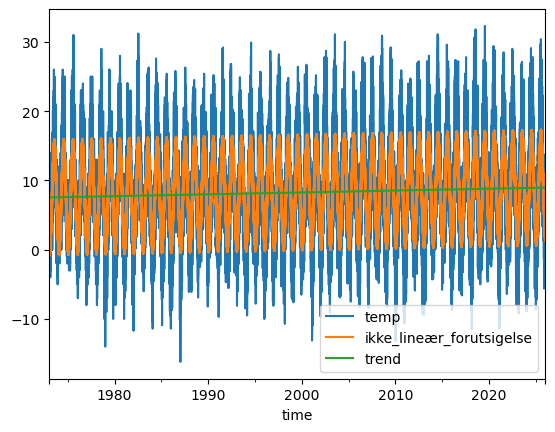

In [19]:
data.plot(y=['temp', 'ikke_lineær_forutsigelse', 'trend'])

Vi plotter den årlige forutsigelsen.

For å se om vi fanger den årlige svingningen plotter vi for en kortere tidsperiode:

<Axes: xlabel='time'>

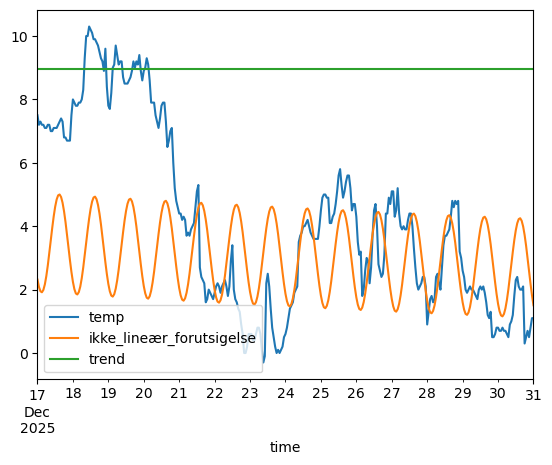

In [24]:
data.loc[end - timedelta(days=14): end].plot(y=['temp', 'ikke_lineær_forutsigelse', 'trend'])

Vi kan se hva forskjellen mellom forutsigelse og faktisk temperatur er:

In [21]:
data['residual'] = data['temp'] - data['ikke_lineær_forutsigelse']

Gjennomsnittlig feil i forutsigelse av temperatur:

In [22]:
np.sqrt(np.mean(data['residual']**2))

np.float64(3.4741439635560885)

Vi vurderer om residualet er normalfordelt.

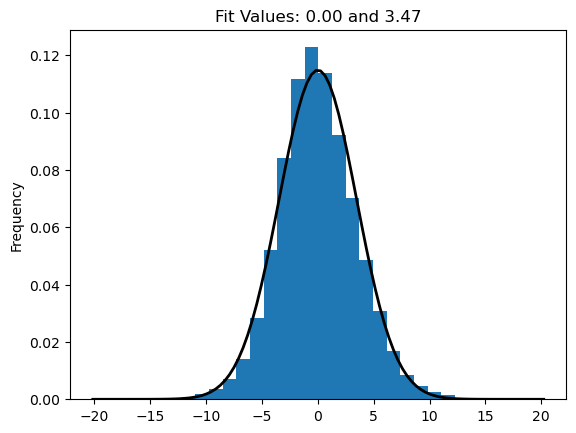

In [23]:
mu, std = scipy.stats.norm.fit(data['residual'])
data['residual'].plot(kind='hist', bins=30, density=True)
range = np.arange(-10, 10, 0.01)
# plt.plot(range, norm.pdf(range,0,4))
xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title);

**Dette ser normalfordelt ut!**